<div style="font-family: 'Times New Roman', serif; line-height: 1.3;">

# Onderzoek naar CO₂-Uitstoot

**Auteurs:** Lucas Hoetink, Lucas van Hamersveld, Robin Djerahian

**Datum:** 30 mei 2026

<br>

---

## Samenvatting

In dit onderzoek onderzoeken wij welke persoonlijke en mobiliteitsgebonden factoren de jaarlijkse CO₂-uitstoot van individuen verklaren. Wij analyseren een dataset van 1500 burgers met behulp van beschrijvende statistieken, correlatie- en regressieanalyse, kansrekening, visualisatie en een statistische toets.

<br>

---

## Inhoudsopgave

1. [Inleiding & Onderzoeksvraag](#Inleiding-&-Onderzoeksvraag)
2. [Hypothese](#Hypothese)
3. [Beschrijvende Statistieken](#Beschrijvende-Statistieken)
4. [Visualisatie van de Dataset](#Visualisatie-van-de-Dataset)
5. [Preparatie van de Dataset](#Preparatie-van-de-Dataset)
6. [Kansrekening](#Kansrekening)
7. [Statistische Toets](#Statistische-Toets)
8. [Lineaire Regressie](#Lineaire-Regressie)
9. [Logistische Regressie](#Logistische-Regressie)
10. [Conclusie](#Conclusie)
11. [Testen van de Modellen](#Testen-van-de-Modellen)

<br>

---

</div>


<div style="font-family: 'Times New Roman', serif; line-height: 1.3;">

# Inleiding & Onderzoeksvraag

Het mobiliteitsgedrag van burgers speelt een sleutelrol bij de uitstoot van broeikasgassen en het behalen van de nationale klimaatdoelstellingen. In dit onderzoek stellen wij de volgende vraagstellingen centraal:

- *Welke persoonlijke en mobiliteitsgebonden factoren verklaren verschillen in de jaarlijkse CO₂-uitstoot tussen burgers?*
- *In welke mate kunnen wij de individuele uitstoot nauwkeurig voorspellen op basis van een combinatie van sociaaldemografische kenmerken en mobiliteitsgedrag?*

<br>

---

</div>

<div style="font-family: 'Times New Roman', serif; line-height: 1.3;">

# Voorbereiding van het notebook

In deze stap laden wij alle benodigde bibliotheken en de dataset. Wij maken gebruik van:

- **NumPy & Pandas** — voor dataverwerking en berekeningen
- **SciPy** — voor statistische toetsen (Shapiro-Wilk, Mann-Whitney U, Wilcoxon)
- **Matplotlib & Seaborn** — voor visualisaties (histogrammen, boxplots, heatmaps)
- **Scikit-learn** — voor machine-learning modellen (lineaire regressie, logistische regressie), KFold cross-validatie, train-testsplitsing, standaardisatie en evaluatiemetrics

De dataset wordt direct geladen vanuit de GitHub-repository en bevat gegevens van **1500 burgers**.

<br>

</div>


In [ ]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold, train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, root_mean_squared_error, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance

df = pd.read_excel('https://github.com/EchoinSilences/WiskundePortfolioHHS/raw/main/Mobiliteitsdata.xlsx')


<div style="font-family: 'Times New Roman', serif; line-height: 1.3;">

---

# Beschrijvende Statistieken

In dit hoofdstuk berekenen en interpreteren wij de belangrijkste beschrijvende statistieken van de dataset. Wij doorlopen de volgende stappen:

**Stap 1 — Datacleaning**

Eerst controleren wij de dataset op problemen:

- **Missende waarden** worden geïmputeerd met de mediaan (numerieke kolommen) of de modus (categoriale kolommen).
- **Negatieve waarden** in kolommen zoals `km_auto_per_jaar`, `jaarsalaris_eu` en `co2_uitstoot_per_jaar_KG` worden vervangen door de mediaan van de geldige waarden.
- **Onmogelijke nulwaarden** bij `leeftijd` en `gewicht_KG` worden vervangen door de mediaan.
- **Uitschieters** worden gesignaleerd via de IQR-methode. Niet alle uitschieters worden verwijderd — hoge kilometerstanden kunnen realistisch zijn.

**Stap 2 — Beschrijvende statistieken**

Na de opschoning berekenen wij voor elke numerieke variabele:

- **Gemiddelde** — het rekenkundig gemiddelde van de waarden
- **Mediaan** — de middelste waarde na rangschikking
- **Modus** — de meest voorkomende waarde
- **Standaardafwijking** — de mate van spreiding rondom het gemiddelde
- **Minimum en maximum** — het volledige bereik van de variabele

</div>


In [ ]:
# Python: Ga na of er missende/niet kloppende/extreme waarden zijn in de dataset
# en ga hier op een adequate manier mee om.

# ── 1. Missende waarden ───────────────────────────────────────────────────────
print("--- Missende waarden per kolom ---\n")
print(df.isnull().sum()[df.isnull().sum() > 0])

for col in df.columns:
    if df[col].isnull().any():
        if df[col].dtype in ['float64', 'int64']:
            df[col] = df[col].fillna(df[col].median())
        else:
            df[col] = df[col].fillna(df[col].mode()[0])

print("\nMissende waarden na imputatie:", df.isnull().sum().sum())

# ── 2. Negatieve waarden (logisch onmogelijk) ─────────────────────────────────
niet_negatief = [
    'jaarsalaris_eu', 'km_auto_per_jaar', 'km_fiets_per_jaar',
    'km_ov_per_jaar', 'km_vliegtuig_per_jaar', 'dagen_in_buitenland_per_jaar',
    'co2_uitstoot_per_jaar_KG', 'leeftijd', 'gewicht_KG', 'huishouden_grootte'
]

print("\n\n--- Negatieve waarden per kolom ---\n")
for col in niet_negatief:
    n_neg = (df[col] < 0).sum()
    if n_neg > 0:
        print(f"  {col}: {n_neg} negatieve waarde(n)")

for col in niet_negatief:
    mediaan = df.loc[df[col] >= 0, col].median()
    df.loc[df[col] < 0, col] = mediaan

print("Negatieve waarden gecorrigeerd.")

# ── 3. Onmogelijke nulwaarden (leeftijd en gewicht kunnen nooit 0 zijn) ────────
nul_onmogelijk = ['leeftijd', 'gewicht_KG']

print("\n\n--- Onmogelijke nulwaarden ---\n")
for col in nul_onmogelijk:
    n_nul = (df[col] == 0).sum()
    if n_nul > 0:
        print(f"  {col}: {n_nul} nulwaarde(n) gevonden")
        mediaan = df.loc[df[col] > 0, col].median()
        df.loc[df[col] == 0, col] = mediaan
        print(f"  → vervangen door mediaan ({mediaan:.1f})")
    else:
        print(f"  {col}: geen nulwaarden")

# ── 4. Uitschieters via IQR-methode (signalering, niet automatisch verwijderen) ─
numeric_cols = df.select_dtypes(include='number').columns.drop('persoon_ID', errors='ignore')

print("\n\n--- Mogelijke uitschieters per kolom (IQR-methode) ---\n")
for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    ondergrens = q1 - 1.5 * iqr
    bovengrens = q3 + 1.5 * iqr
    n_uitschieters = ((df[col] < ondergrens) | (df[col] > bovengrens)).sum()
    if n_uitschieters > 0:
        print(f"  {col}: {n_uitschieters} mogelijke uitschieter(s) "
              f"(buiten [{ondergrens:.1f}, {bovengrens:.1f}])")

print("\nNota: uitschieters worden niet automatisch verwijderd.")
print("      Hoge kilometer- of salariswaarden kunnen realistisch zijn.")
print(f"\nDataset na opschoning: {df.shape}")
df.describe().round(2)


 --- Missende waarden per kolom ---

jaarsalaris_eu              1
stad                        1
opleiding_niveau            1
autobezit                   1
co2_uitstoot_per_jaar_KG    7
dtype: int64

Missende waarden na imputatie: 0


 --- Negatieve waarden per kolom ---

  jaarsalaris_eu: 7 negatieve waarde(n)
  km_auto_per_jaar: 12 negatieve waarde(n)
  km_ov_per_jaar: 41 negatieve waarde(n)
Negatieve waarden gecorrigeerd.

Dataset na opschoning: (1500, 22)


,persoon_ID,leeftijd,gewicht_KG,jaarsalaris_eu,huishouden_grootte,km_auto_per_jaar,km_fiets_per_jaar,km_ov_per_jaar,km_vliegtuig_per_jaar,dagen_thuiswerken_per_week_pro_rato,dagen_kantoorwerken_per_week_pro_rato,dagen_in_buitenland_per_jaar,co2_uitstoot_per_jaar_KG
count,1500.00,1500.00,1500.00,1500.00,1500.00,1500.00,1500.00,1500.00,1500.00,1500.00,1500.00,1500.00,1500.00
mean,560229.09,47.99,75.15,40303.87,3.03,8685.77,1794.18,3042.00,1072.28,2.53,2.47,14.49,4911.24
std,260939.29,18.13,14.80,14664.02,1.41,6959.66,753.99,1409.22,748.65,1.67,1.67,8.70,3414.94
min,102295.00,0.00,0.00,294.11,1.00,0.00,0.00,3.06,0.00,0.00,0.00,0.00,0.00
25%,332525.75,32.00,65.64,30188.84,2.00,0.00,1503.42,2069.28,471.54,1.00,1.00,7.00,1471.52
50%,563847.00,47.00,75.79,40576.27,3.00,9433.98,1910.00,3058.34,1052.14,3.00,2.00,15.00,4677.28
75%,792686.75,64.00,84.94,50280.61,4.00,13842.73,2286.18,3991.54,1588.56,4.00,4.00,22.00,7471.17
max,999493.00,79.00,117.76,93826.85,5.00,34618.87,3672.70,8018.06,3808.20,5.00,5.00,29.00,18098.44


In [ ]:
# Python: Bepaal voor elke kolom de relevante beschrijvende statistieken
# (berekend op de opgeschoonde dataset; persoon_ID wordt uitgesloten)

numeric_cols = df.select_dtypes(include='number').columns.drop('persoon_ID', errors='ignore')
data = []

for col in numeric_cols:
    col_data = df[col]
    data.append({
        'kolom':      col,
        'gemiddelde': col_data.mean(),
        'mediaan':    col_data.median(),
        'modus':      col_data.mode()[0],
        'std':        col_data.std(),
        'minimum':    col_data.min(),
        'maximum':    col_data.max(),
    })

describing_df = pd.DataFrame(data).set_index('kolom')
display(describing_df.round(2))
df.info()


<div style="font-family: 'Times New Roman', serif; line-height: 1.3;">

---

# Visualisatie van de Dataset

In dit hoofdstuk visualiseren wij de verdeling van geselecteerde variabelen met behulp van histogrammen. Wij kiezen de volgende twee onafhankelijke variabelen die naar verwachting invloed hebben op de jaarlijkse CO₂-uitstoot:

- `km_auto_per_jaar` — het aantal autokilometers per jaar per persoon
- `km_fiets_per_jaar` — het aantal fietskilometers per jaar per persoon

De afhankelijke variabele is `co2_uitstoot_per_jaar_KG`. Daarna toetsen wij met de **Shapiro-Wilk toets** of elk van de drie verdelingen normaal verdeeld is (H₀: de data is normaal verdeeld, α = 0,05). De uitkomst van deze toets bepaalt welke statistische toets wij verderop in het notebook mogen gebruiken.

</div>


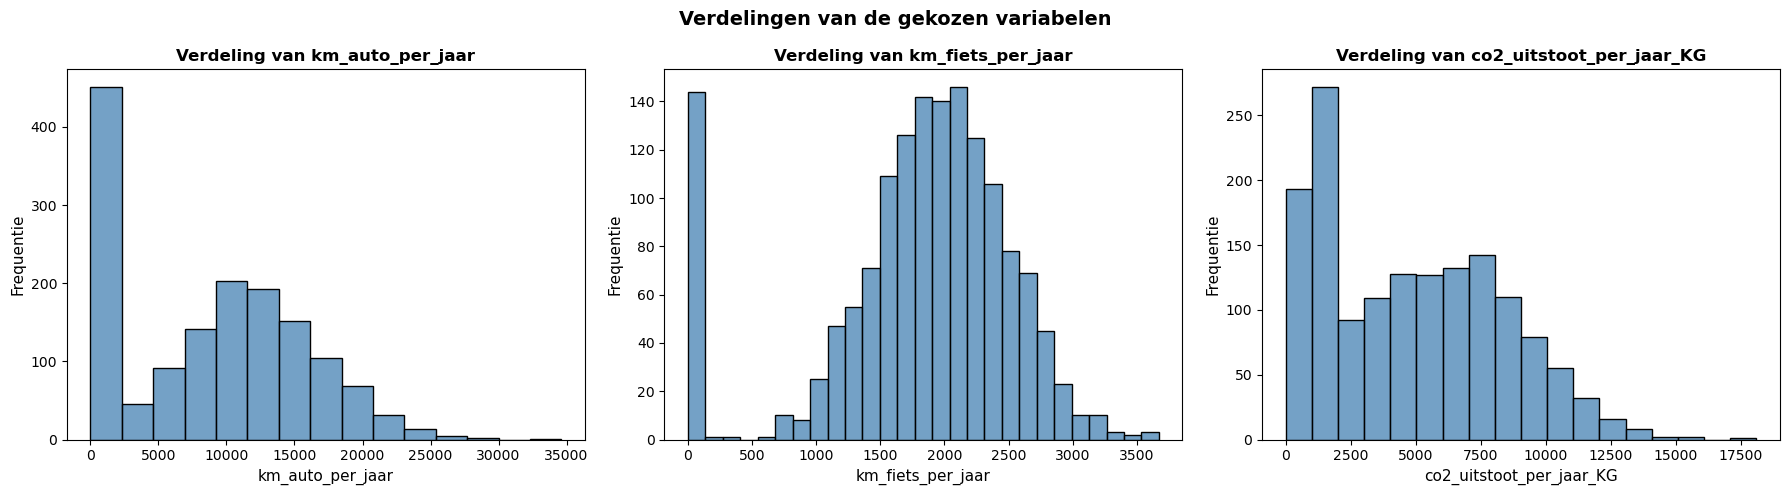

In [129]:
# Python: Kies 2 onafhankelijke variabelen waarvan je denkt dat het invloed kan hebben
# op de jaarlijkse CO2-uitstoot. Visualiseer de verdeling van deze twee variabelen
# en de verdeling van de afhankelijke variabele (CO2-uitstoot).
# Wij kiezen km_auto_per_jaar en km_fiets_per_jaar tegenover co2_uitstoot_per_jaar_KG.

gekozen_vars = ['km_auto_per_jaar', 'km_fiets_per_jaar']
target = 'co2_uitstoot_per_jaar_KG'
alle_vars = gekozen_vars + [target]

# ── Histogrammen ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, var in zip(axes, alle_vars):
    sns.histplot(df[var], ax=ax, color='steelblue')
    ax.set_title(f'Verdeling van {var}', fontsize=12, fontweight='bold')
    ax.set_xlabel(var, fontsize=11)
    ax.set_ylabel('Frequentie', fontsize=11)

plt.suptitle('Verdelingen van de gekozen variabelen', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Python: Toets, met behulp van statistiek, of de verdelingen normaal verdeeld zijn.
# Shapiro-Wilk toets voor de drie gekozen variabelen.

resultaten = []
for col in gekozen_vars + [target]:
    stat, p = stats.shapiro(df[col])
    resultaten.append({
        'kolom': col,
        'Shapiro-W': round(stat, 4),
        'p-waarde': f'{p:.3e}',
        'Normaal verdeeld': 'Ja' if p > 0.05 else 'Nee'
    })

shapiro_df = pd.DataFrame(resultaten).set_index('kolom')
display(shapiro_df)


,Shapiro-W,p-waarde,Normaal verdeeld
kolom,,,
km_auto_per_jaar,0.9154,0.0,Nee
km_fiets_per_jaar,0.9072,0.0,Nee
co2_uitstoot_per_jaar_KG,0.9398,0.0,Nee


<div style="font-family: 'Times New Roman', serif; line-height: 1.3;">

### Interpretatie van de verdelingen

Op basis van de histogrammen en de Shapiro-Wilk toets kunnen wij de volgende conclusies trekken:

- **`km_auto_per_jaar`** is rechts-scheef en bevat veel nulwaarden (personen zonder auto). Normaliteit wordt verworpen (p < 0,05).
- **`km_fiets_per_jaar`** is niet normaal verdeeld en vertoont een duidelijke piek bij nul (personen die niet fietsen). Normaliteit wordt verworpen.
- **`co2_uitstoot_per_jaar_KG`** is rechts-scheef en bevat waarschijnlijk meerdere subgroepen (bijv. met/zonder auto). Normaliteit wordt verworpen.

Voor alle drie de variabelen geldt: omdat p < 0,05 verwerpen wij H₀ (normaal verdeeld). Wij moeten daarom bij de statistische toets kiezen voor een **niet-parametrische methode**.

> **Opmerking:** nulwaarden zijn geen uitschieters — zij vertegenwoordigen personen die van dat vervoermiddel geen gebruik maken.

</div>


<div style="font-family: 'Times New Roman', serif; line-height: 1.3;">

---

# Preparatie van de Dataset

In dit hoofdstuk transformeren wij de data zodat deze geschikt is voor machine-learning modellen. Wij onderscheiden drie typen variabelen en passen per type een andere transformatie toe.
Het getransformeerde dataframe wordt opgeslagen als `df_transformed`; de originele dataset `df` blijft ongewijzigd. Vervolgens wordt een **correlatiematrix** opgesteld om de samenhang tussen alle numerieke variabelen en de target `co2_uitstoot_per_jaar_KG` te visualiseren.

</div>


In [ ]:
# Python: Voer de transformatie uit.
# Let op dat je de getransformeerde variabelen in een nieuw dataframe opslaat,
# zodat je de oorspronkelijke waarden behoudt.

# ── Controleer de categorieën van nominale variabelen ─────────────────────────
print("--- Unieke categorieën per nominale variabele ---\n")
nominaal_check = ['geslacht', 'burgerlijke_staat', 'stad', 'provincie',
                  'autobezit', 'fietsbezit', 'elektrisch_auto', 'gebruik_carsharing',
                  'opleiding_niveau']
for col in nominaal_check:
    print(f"  {col}: {sorted(df[col].dropna().unique())}")

# ── Variabelen per meetniveau ─────────────────────────────────────────────────
# gebruik_carsharing behandelen we als ordinaal als het een volgorde heeft
# (nooit < heel soms < soms < vaak < altijd); anders nominaal.
carsharing_volgorde = {
    'nooit': 0, 'heel soms': 1, 'soms': 2, 'vaak': 3, 'altijd': 4
}

carsharing_vals = set(df['gebruik_carsharing'].str.lower().unique())
carsharing_is_ordinaal = carsharing_vals.issubset(set(carsharing_volgorde.keys()))
print(f"\ngebruik_carsharing als ordinaal behandelen: {carsharing_is_ordinaal}")

if carsharing_is_ordinaal:
    nominaal = ['geslacht', 'burgerlijke_staat', 'stad', 'provincie',
                'autobezit', 'fietsbezit', 'elektrisch_auto']
    ordinaal = ['opleiding_niveau', 'gebruik_carsharing']
else:
    nominaal = ['geslacht', 'burgerlijke_staat', 'stad', 'provincie',
                'autobezit', 'fietsbezit', 'elektrisch_auto', 'gebruik_carsharing']
    ordinaal = ['opleiding_niveau']

ratio = ['leeftijd', 'gewicht_KG', 'jaarsalaris_eu', 'huishouden_grootte',
         'km_auto_per_jaar', 'km_fiets_per_jaar', 'km_ov_per_jaar',
         'km_vliegtuig_per_jaar', 'dagen_thuiswerken_per_week_pro_rato',
         'dagen_kantoorwerken_per_week_pro_rato', 'dagen_in_buitenland_per_jaar']

target = 'co2_uitstoot_per_jaar_KG'

# ── 1. One-hot encoding voor nominale variabelen (drop_first=True voorkomt multicollineariteit) ──
df_ohe = pd.get_dummies(df[nominaal], drop_first=True).astype(int)

# ── 2. Ordinal encoding ────────────────────────────────────────────────────────
opleiding_volgorde = {
    'geen': 0, 'basisonderwijs': 1, 'vmbo': 2, 'mbo': 3,
    'havo_vwo': 4, 'hbo': 5, 'wo': 6
}

df_ord = df[['opleiding_niveau']].copy()
df_ord['opleiding_niveau'] = (df_ord['opleiding_niveau']
                               .str.lower()
                               .map(opleiding_volgorde))
df_ord['opleiding_niveau'] = (df_ord['opleiding_niveau']
                               .fillna(df_ord['opleiding_niveau'].median())
                               .astype(int))

if carsharing_is_ordinaal:
    df_ord['gebruik_carsharing'] = (df['gebruik_carsharing']
                                     .str.lower()
                                     .map(carsharing_volgorde))
    df_ord['gebruik_carsharing'] = (df_ord['gebruik_carsharing']
                                     .fillna(df_ord['gebruik_carsharing'].median())
                                     .astype(int))

# Controleer op ongemapte waarden (NaN na mapping = categorie niet in woordenboek)
print("\n--- Controle ongemapte opleiding_niveau waarden ---")
ongemapped = df['opleiding_niveau'].str.lower()[
    ~df['opleiding_niveau'].str.lower().isin(opleiding_volgorde.keys())
]
if ongemapped.any():
    print(f"  Ongemapte waarden: {ongemapped.unique()}")
else:
    print("  Geen ongemapte waarden.")

# ── 3. Standaardisatie voor ratio-variabelen ──────────────────────────────────
scaler = StandardScaler()
df_ratio_scaled = pd.DataFrame(
    scaler.fit_transform(df[ratio]),
    columns=ratio,
    index=df.index
)

# ── 4. Alles samenvoegen in een nieuw dataframe ───────────────────────────────
df_transformed = pd.concat([df_ratio_scaled, df_ord, df_ohe, df[[target]]], axis=1)

print(f"\nOrigineel dataframe:       {df.shape}")
print(f"Getransformeerd dataframe: {df_transformed.shape}")
display(df_transformed.head())


Origineel dataframe:     (1500, 22)
Getransformeerd dataframe: (1500, 69)


,leeftijd,gewicht_KG,jaarsalaris_eu,huishouden_grootte,km_auto_per_jaar,km_fiets_per_jaar,km_ov_per_jaar,km_vliegtuig_per_jaar,dagen_thuiswerken_per_week_pro_rato,dagen_kantoorwerken_per_week_pro_rato,...,fietsbezit_ja,fietsbezit_nee,elektrisch_auto_ja,elektrisch_auto_nee,gebruik_carsharing_Altijd,gebruik_carsharing_Heel soms,gebruik_carsharing_Nooit,gebruik_carsharing_Soms,gebruik_carsharing_Vaak,co2_uitstoot_per_jaar_KG
0,0.110910,-1.520186,0.525254,1.395203,0.658337,0.326850,0.131999,-0.790441,0.878218,-0.878218,...,1,0,0,1,0,0,1,0,0,7591.93
1,0.938319,-0.714335,1.016756,-0.731631,0.940606,-2.380371,-0.527443,0.469083,1.476731,-1.476731,...,0,1,0,1,0,1,0,0,0,8742.25
2,0.055749,1.063001,-0.734702,-0.731631,1.605134,-0.336615,1.037950,-0.587649,0.878218,-0.878218,...,1,0,1,0,1,0,0,0,0,4513.56
3,-0.771661,0.357205,0.283059,-0.731631,0.179627,0.042110,0.969343,0.259971,0.279705,-0.279705,...,1,0,0,1,0,1,0,0,0,6904.41
4,0.662516,-0.193776,1.104688,-0.731631,1.089625,0.075477,-0.785004,0.806683,-1.515833,1.515833,...,1,0,1,0,0,0,1,0,0,4420.80


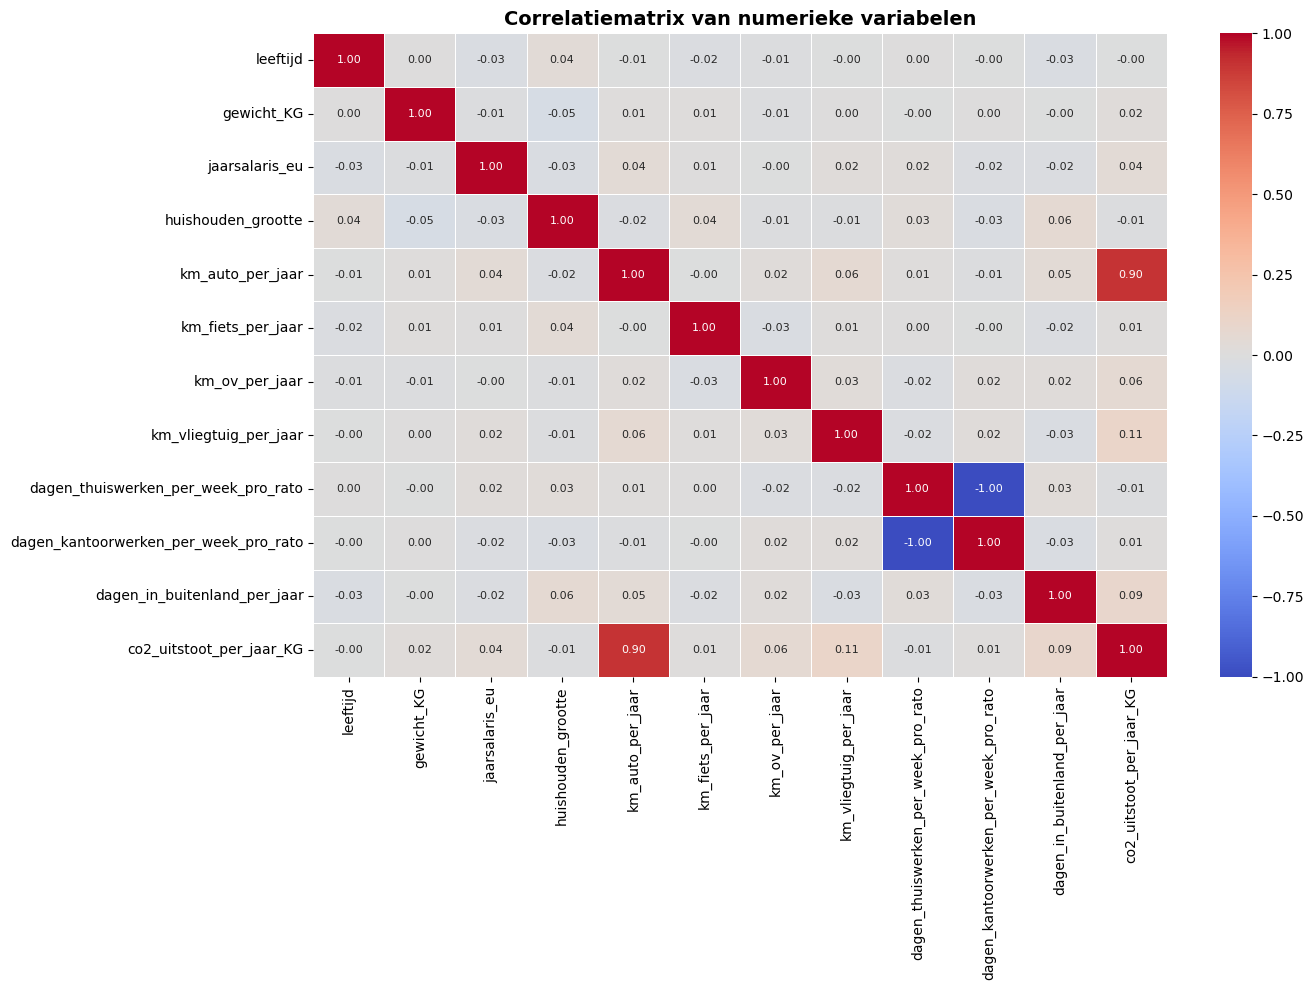


Correlaties met 'co2_uitstoot_per_jaar_KG' (gesorteerd):


,co2_uitstoot_per_jaar_KG
km_auto_per_jaar,0.903
km_vliegtuig_per_jaar,0.106
dagen_in_buitenland_per_jaar,0.087
km_ov_per_jaar,0.061
jaarsalaris_eu,0.043
gewicht_KG,0.016
dagen_kantoorwerken_per_week_pro_rato,0.013
km_fiets_per_jaar,0.010
leeftijd,-0.005
huishouden_grootte,-0.012


In [ ]:
# Python: Zorg dat je inzicht krijgt in de relaties tussen alle variabelen.
# Correlatiematrix van alle ratio-variabelen + target

ratio_cols = ratio + [target]
corr_matrix = df[ratio_cols].corr()

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    ax=ax,
    annot_kws={'size': 8}
)
ax.set_title('Correlatiematrix van numerieke variabelen', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Top correlaties met de target
print(f"\nCorrelaties met '{target}' (gesorteerd):")
corr_target = corr_matrix[[target]].drop(target).sort_values(target, ascending=False).round(3)
display(corr_target)

# ── Scatterplot van de sterkste correlatie met regressielijn ──────────────────
sterkste_var = corr_target[target].abs().idxmax()
r_waarde     = corr_target.loc[sterkste_var, target]

fig2, ax2 = plt.subplots(figsize=(8, 5))
sns.regplot(
    data=df,
    x=sterkste_var,
    y=target,
    ax=ax2,
    scatter_kws={'alpha': 0.3, 'color': 'steelblue'},
    line_kws={'color': 'crimson'}
)
ax2.set_title(
    f'Relatie tussen {sterkste_var} en {target}\n(r = {r_waarde:.3f})',
    fontsize=12, fontweight='bold'
)
ax2.set_xlabel(sterkste_var, fontsize=11)
ax2.set_ylabel('CO₂-uitstoot per jaar (KG)', fontsize=11)
plt.tight_layout()
plt.show()

print(f"\nSterkste correlatie: {sterkste_var} (r = {r_waarde:.3f})")
print("→ Dit is een zeer sterke positieve correlatie.")
print("→ Meer autokilometers gaan samen met een hogere CO₂-uitstoot.")
print("→ Let op: correlatie is geen bewijs voor causaliteit.")


<div style="font-family: 'Times New Roman', serif; line-height: 1.3;">

---

# Kansrekening

In dit hoofdstuk berekenen wij de kans dat een willekeurig gekozen persoon uit de dataset meer dan **5.000 KG CO₂** per jaar uitstoot. Wij maken gebruik van de **standaard normaalverdeling** en doorlopen de volgende stappen:

1. Bereken het gemiddelde (μ) en de standaardafwijking (σ) van `co2_uitstoot_per_jaar_KG`
2. Bereken de z-score: $z = \dfrac{x - \mu}{\sigma}$, met $x = 5000$
3. Bepaal de kans via de cumulatieve verdelingsfunctie: $P(\text{CO}_2 > 5000) = 1 - \Phi(z)$

waarbij $\Phi$ de cumulatieve verdelingsfunctie (CDF) van de standaard normaalverdeling is.

</div>


In [ ]:
# Wat is de kans dat een willekeurig persoon MEER DAN 5000 KG CO2 uitstoot?
# Gebruik de standaard normaal verdeling in de berekening.

grenswaarde = 5000

mu    = df[target].mean()
sigma = df[target].std()

# Standaardiseren: z = (x - mu) / sigma
z = (grenswaarde - mu) / sigma

kans_cdf = 1 - stats.norm.cdf(z)

print(f"Gemiddelde (mu):    {mu:.2f} KG")
print(f"Standaardafw. (s):  {sigma:.2f} KG")
print(f"Z-score:            {z:.4f}")
print(f"P(CO2 > {grenswaarde} KG) = 1 - Phi({z:.4f}) = {kans_cdf:.4f}  ({kans_cdf*100:.2f}%)")
print()
print("Opmerking: dit is een theoretische normaalbenadering, omdat de werkelijke")
print("verdeling niet volledig normaal is (zie Shapiro-Wilk toets).")

# ── Empirische kans ter verificatie ───────────────────────────────────────────
empirische_kans = (df[target] > grenswaarde).mean()
print(f"\nEmpirische kans (werkelijk aandeel in dataset): {empirische_kans:.4f}  "
      f"({empirische_kans*100:.2f}%)")
print("→ Vergelijk dit met de normaalbenadering hierboven.")


Gemiddelde (mu):    4911.24 KG
Standaardafw. (s):  3414.94 KG
Z-score:            0.0260
P(CO2 > 5000 KG) = 1 - Phi(0.0260) = 0.4896  (48.96%)


<div style="font-family: 'Times New Roman', serif; line-height: 1.3;">

---

# Hypothese

Wij onderzoeken of er een statistisch significant verschil bestaat in de jaarlijkse CO₂-uitstoot tussen personen **met** en **zonder** een auto. De gekozen categoriale variabele is `autobezit`.

**H₀:** De verdeling van de jaarlijkse CO₂-uitstoot verschilt **niet** tussen personen met en zonder een auto.

**H₁:** De verdeling van de jaarlijkse CO₂-uitstoot verschilt **wel** tussen personen met en zonder een auto.

Significantieniveau: **α = 0,05**

<br>

</div>


<div style="font-family: 'Times New Roman', serif; line-height: 1.3;">

---

# Statistische Toets

In dit hoofdstuk voeren wij een statistische toets uit om de hypothese over `autobezit` te toetsen. Omdat uit de Shapiro-Wilk toets is gebleken dat de verdeling van `co2_uitstoot_per_jaar_KG` **niet normaal verdeeld** is, gebruiken wij de **Mann-Whitney U toets** — een niet-parametrisch alternatief voor de onafhankelijke t-toets dat geen normaliteitsaanname vereist.

De dataset wordt opgesplitst in twee groepen op basis van `autobezit`. Wij visualiseren het verschil tussen de groepen met een **boxplot** en een **violinplot**, en voeren vervolgens de toets uit. Op basis van de p-waarde en α = 0,05 trekken wij een conclusie over H₀.

</div>


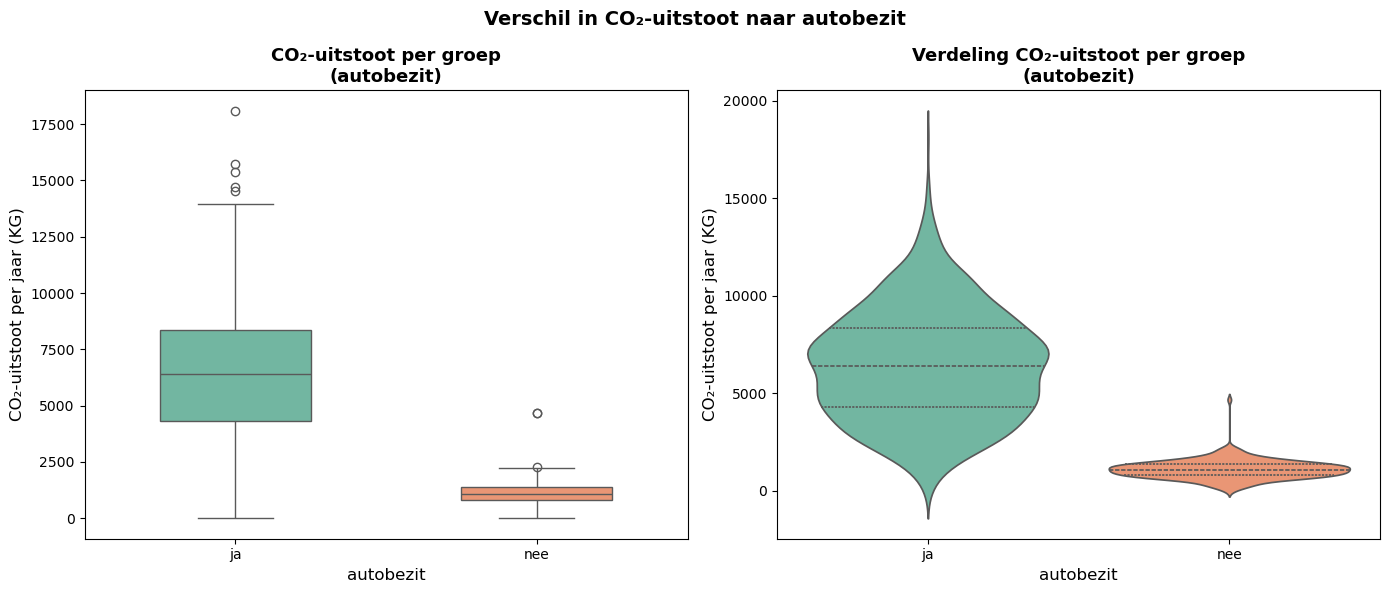

Gemiddelde CO₂-uitstoot per groep:


,mean,median,std,count
autobezit,,,,
ja,6454.22,6414.31,2836.57,1067
nee,1109.04,1076.22,490.22,433


In [134]:
# Python: Maak de geschikte plotjes om het verschil tussen de groepen te visualiseren.
# Groepsvariabele: autobezit | Afhankelijke variabele: co2_uitstoot_per_jaar_KG

groep_var = 'autobezit'
groepen   = df[groep_var].unique()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Boxplot ───────────────────────────────────────────────────────────────────
sns.boxplot(data=df, x=groep_var, y=target, hue=groep_var, legend=False,
            ax=axes[0], palette='Set2', width=0.5)
axes[0].set_title(f'CO₂-uitstoot per groep\n({groep_var})', fontsize=13, fontweight='bold')
axes[0].set_xlabel(groep_var, fontsize=12)
axes[0].set_ylabel('CO₂-uitstoot per jaar (KG)', fontsize=12)

# ── Violin plot ───────────────────────────────────────────────────────────────
sns.violinplot(data=df, x=groep_var, y=target, hue=groep_var, legend=False,
               ax=axes[1], palette='Set2', inner='quartile')
axes[1].set_title(f'Verdeling CO₂-uitstoot per groep\n({groep_var})', fontsize=13, fontweight='bold')
axes[1].set_xlabel(groep_var, fontsize=12)
axes[1].set_ylabel('CO₂-uitstoot per jaar (KG)', fontsize=12)

plt.suptitle(f'Verschil in CO₂-uitstoot naar {groep_var}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Gemiddelde per groep
print("Gemiddelde CO₂-uitstoot per groep:")
display(df.groupby(groep_var)[target].agg(['mean', 'median', 'std', 'count']).round(2))


In [ ]:
# Python: Voer de statistische toets uit.
# Omdat de verdelingen niet normaal zijn (zie Shapiro-Wilk), gebruiken wij
# de Mann-Whitney U toets (niet-parametrisch alternatief voor de t-toets).
#
# H0: De verdeling van CO₂-uitstoot verschilt niet tussen de autobezit-groepen
# H1: De verdeling van CO₂-uitstoot verschilt wel tussen de autobezit-groepen
# Significantieniveau: alpha = 0.05

alpha = 0.05

groepen = df[groep_var].unique()
print(f"Groepen in '{groep_var}': {groepen}\n")

# ── Normaliteit per groep controleren (bevestiging toetskeuze) ────────────────
print("--- Shapiro-Wilk per groep (onderbouwing toetskeuze) ---")
for groep in groepen:
    waarden = df.loc[df[groep_var] == groep, target]
    stat_sw, p_sw = stats.shapiro(waarden)
    print(f"  autobezit '{groep}': W = {stat_sw:.4f}, p = {p_sw:.3e} "
          f"→ {'normaal' if p_sw > 0.05 else 'NIET normaal'}")

print()

# Splits in twee groepen
groep_waarden = [df.loc[df[groep_var] == g, target].values for g in groepen]

# ── Mann-Whitney U toets ───────────────────────────────────────────────────────
u_stat, p_waarde = stats.mannwhitneyu(*groep_waarden, alternative='two-sided')

print("=== Mann-Whitney U toets ===")
print(f"U-statistiek: {u_stat:.2f}")
if p_waarde < 0.001:
    print(f"p-waarde:     p < 0,001")
else:
    print(f"p-waarde:     {p_waarde:.4f}")

# ── Effectgrootte: rank-biserial correlatie ───────────────────────────────────
n1 = len(groep_waarden[0])
n2 = len(groep_waarden[1])
rank_biserial = abs((2 * u_stat) / (n1 * n2) - 1)
print(f"Effectgrootte (rank-biserial r): {rank_biserial:.3f}")

# Interpretatie effectgrootte
if rank_biserial >= 0.5:
    effect_label = "groot"
elif rank_biserial >= 0.3:
    effect_label = "middelgroot"
else:
    effect_label = "klein"
print(f"→ Effect is {effect_label} (r ≥ 0,5 = groot, ≥ 0,3 = middelgroot)")

print()
print("--- Gemiddelde/mediaan CO₂ per groep ---")
display(df.groupby(groep_var)[target].agg(['mean', 'median', 'std', 'count']).round(2))
print()

if p_waarde < alpha:
    beter_label = "met" if df.loc[df[groep_var] == groepen[0], target].median() > \
                           df.loc[df[groep_var] == groepen[1], target].median() else "zonder"
    print(f"Conclusie: p < 0,001 (< alpha = {alpha})")
    print(f"→ H0 verworpen: er is een statistisch significant verschil in de verdeling")
    print(f"  van CO₂-uitstoot tussen personen met en zonder {groep_var}.")
    print(f"  Personen MET een auto hebben een duidelijk hogere mediane uitstoot.")
else:
    print(f"Conclusie: p = {p_waarde:.4f} >= alpha = {alpha}")
    print(f"→ H0 niet verworpen: er is geen statistisch significant verschil in de")
    print(f"  verdeling van CO₂-uitstoot tussen personen met en zonder {groep_var}.")


Groepen in 'autobezit': ['ja' 'nee']

Mann-Whitney U toets
U-statistiek: 455357.00
p-waarde:     0.0000

Conclusie: p = 0.0000 < alpha = 0.05
→ H0 verworpen: er is een statistisch significant verschil in CO₂-uitstoot
  tussen personen met en zonder autobezit.


<div style="font-family: 'Times New Roman', serif; line-height: 1.3;">

---

# Lineaire Regressie

In dit hoofdstuk bouwen wij een lineair regressiemodel om de jaarlijkse CO₂-uitstoot te voorspellen. Wij doorlopen de volgende stappen:

1. **Train-testsplitsing** — de data wordt opgesplitst in 80% trainset en 20% testset (`random_state=42`)
2. **Model 1** — een lineair regressiemodel getraind op alle variabelen in `df_transformed`
3. **Meest invloedrijke variabelen** — bepaald via **permutation importance**: meet hoeveel slechter het model wordt als een variabele willekeurig door elkaar wordt geschud. Dit is robuuster dan coëfficiënten vergelijken, omdat niet alle variabelen even sterk zijn gestandaardiseerd
4. **Model 2** — een lineair regressiemodel getraind op enkel de top 5 variabelen
5. **20-fold cross-validatie** — beide modellen worden vergeleken via 20-fold CV; per fold worden R² en RMSE bijgehouden
6. **Wilcoxon signed-rank toets** — een niet-parametrische toets bepaalt of het verschil in RMSE tussen de twee modellen statistisch significant is (α = 0,05)

De gebruikte evaluatiemetrics zijn:
- **R²** — verklaarde variantie (1 = perfecte voorspelling, 0 = geen verklarende waarde)
- **RMSE** — wortel van het gemiddelde van de gekwadrateerde voorspelfouten; grote fouten wegen extra zwaar. Uitgedrukt in KG CO₂.

</div>


In [136]:
# Python: Split de data op in een train- en testset. Kies zelf voor een geschikte split.
# Wij gebruiken een 80/20 splitsing (80% train, 20% test).

X = df_transformed.drop(columns=[target])
y = df_transformed[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Trainset:  {X_train.shape[0]} rijen ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Testset:   {X_test.shape[0]} rijen  ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"Aantal features: {X_train.shape[1]}")

Trainset:  1200 rijen (80%)
Testset:   300 rijen  (20%)
Aantal features: 68


In [137]:
# Python: Train een lineair regressiemodel om de jaarlijkse CO₂-uitstoot te voorspellen.

model_all = LinearRegression()
model_all.fit(X_train, y_train)

y_pred = model_all.predict(X_test)

r2   = r2_score(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

print("=== Lineair regressiemodel (alle variabelen) ===")
print(f"R²:   {r2:.4f}")
print(f"RMSE: {rmse:.2f} KG")

=== Lineair regressiemodel (alle variabelen) ===
R²:   0.9370
RMSE: 824.59 KG


Top 5 meest invloedrijke variabelen:


,variabele,coëfficiënt,|coëfficiënt|
0,km_auto_per_jaar,3074.0777,3074.0777
1,elektrisch_auto_nee,1299.3556,1299.3556
2,elektrisch_auto_ja,-1299.3556,1299.3556
3,stad_Nijmegen,-391.9141,391.9141
4,stad_Hoofddorp,229.4526,229.4526



Gekozen top 5: ['km_auto_per_jaar', 'elektrisch_auto_nee', 'elektrisch_auto_ja', 'stad_Nijmegen', 'stad_Hoofddorp']


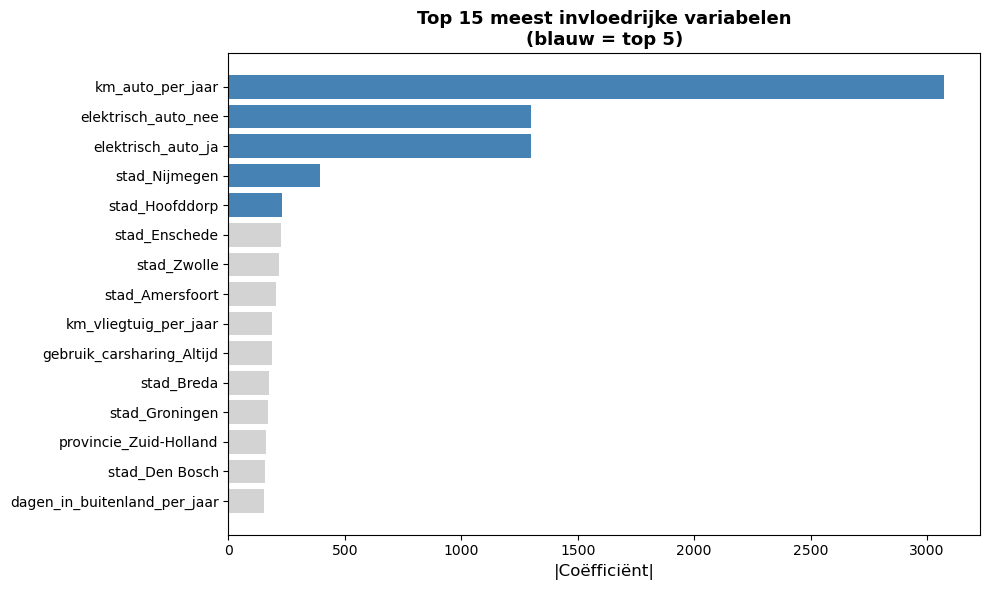

In [ ]:
# Python: Bepaal welke 5 onafhankelijke variabelen de meeste invloed hebben op de voorspelling.
# Wij gebruiken permutation importance: meet hoeveel slechter het model wordt
# als een variabele willekeurig door elkaar wordt geschud.
# Dit is robuuster dan coëfficiënten vergelijken, omdat niet alle variabelen
# even sterk zijn gestandaardiseerd (dummies vs. ratio-variabelen).

from sklearn.inspection import permutation_importance

perm_resultaat = permutation_importance(
    model_all,
    X_test,
    y_test,
    scoring='neg_root_mean_squared_error',
    n_repeats=20,
    random_state=42
)

importance_df = pd.DataFrame({
    'variabele':  X_test.columns,
    'importance': perm_resultaat.importances_mean
}).sort_values('importance', ascending=False).reset_index(drop=True)

print("Top 5 meest invloedrijke variabelen (permutation importance):")
display(importance_df.head(5).round(4))

top5_vars = importance_df.head(5)['variabele'].tolist()
print(f"\nGekozen top 5: {top5_vars}")

# ── Visualisatie ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
top_n   = importance_df.head(15)
colors  = ['steelblue' if v in top5_vars else 'lightgrey' for v in top_n['variabele']]
ax.barh(top_n['variabele'][::-1], top_n['importance'][::-1], color=colors[::-1])
ax.set_xlabel('Permutation importance (gem. RMSE-toename bij permutatie)', fontsize=11)
ax.set_title('Top 15 meest invloedrijke variabelen\n(blauw = top 5)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [139]:
# Python: Train en test nu twee modellen:
# Model 1: met alle variabelen
# Model 2: met de vijf meest invloedrijke variabelen
# Gebruik hiervoor 20-fold cross-validatie.

kf = KFold(n_splits=20, shuffle=True, random_state=42)

scores_m1_r2, scores_m1_rmse = [], []
scores_m2_r2, scores_m2_rmse = [], []

for train_idx, val_idx in kf.split(X):
    # Model 1: alle variabelen
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

    m1 = LinearRegression().fit(X_tr, y_tr)
    p1 = m1.predict(X_val)
    scores_m1_r2.append(r2_score(y_val, p1))
    scores_m1_rmse.append(root_mean_squared_error(y_val, p1))

    # Model 2: top 5 variabelen
    m2 = LinearRegression().fit(X_tr[top5_vars], y_tr)
    p2 = m2.predict(X_val[top5_vars])
    scores_m2_r2.append(r2_score(y_val, p2))
    scores_m2_rmse.append(root_mean_squared_error(y_val, p2))

scores_m1_r2   = np.array(scores_m1_r2)
scores_m1_rmse = np.array(scores_m1_rmse)
scores_m2_r2   = np.array(scores_m2_r2)
scores_m2_rmse = np.array(scores_m2_rmse)

print("20-fold cross-validatie klaar.")
print(f"Model 1 (alle vars) — gemiddelde R²: {scores_m1_r2.mean():.4f}, RMSE: {scores_m1_rmse.mean():.2f}")
print(f"Model 2 (top 5)     — gemiddelde R²: {scores_m2_r2.mean():.4f}, RMSE: {scores_m2_rmse.mean():.2f}")

20-fold cross-validatie klaar.
Model 1 (alle vars) — gemiddelde R²: 0.9076, RMSE: 1015.19
Model 2 (top 5)     — gemiddelde R²: 0.9042, RMSE: 1035.97


In [140]:
# Python: Gebruik de gekozen metric om de nauwkeurigheid van beide modellen te kwantificeren.
# Wij rapporteren zowel R² (verklaarde variantie) als RMSE (gemiddelde afwijking in KG).

resultaten_cv = pd.DataFrame({
    'Model': ['Model 1 (alle variabelen)', 'Model 2 (top 5 variabelen)'],
    'Gem. R²':   [scores_m1_r2.mean(),   scores_m2_r2.mean()],
    'Std. R²':   [scores_m1_r2.std(),    scores_m2_r2.std()],
    'Gem. RMSE': [scores_m1_rmse.mean(), scores_m2_rmse.mean()],
    'Std. RMSE': [scores_m1_rmse.std(),  scores_m2_rmse.std()],
}).set_index('Model')

display(resultaten_cv.round(4))

,Gem. R²,Std. R²,Gem. RMSE,Std. RMSE
Model,,,,
Model 1 (alle variabelen),0.9076,0.0296,1015.1880,174.1098
Model 2 (top 5 variabelen),0.9042,0.0286,1035.9748,173.8118


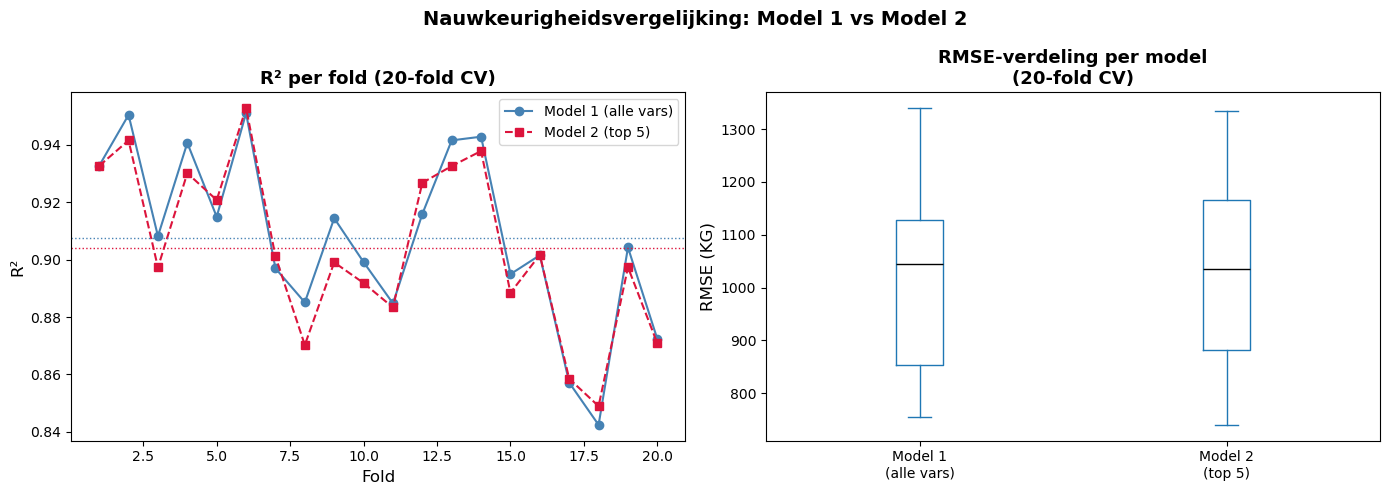

In [141]:
# Python: Maak de geschikte plotjes om het verschil in nauwkeurigheid tussen de twee modellen te visualiseren.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── R² per fold ───────────────────────────────────────────────────────────────
folds = np.arange(1, 21)
axes[0].plot(folds, scores_m1_r2, marker='o', label='Model 1 (alle vars)', color='steelblue')
axes[0].plot(folds, scores_m2_r2, marker='s', label='Model 2 (top 5)', color='crimson', linestyle='--')
axes[0].axhline(scores_m1_r2.mean(), color='steelblue', linewidth=1, linestyle=':')
axes[0].axhline(scores_m2_r2.mean(), color='crimson',   linewidth=1, linestyle=':')
axes[0].set_xlabel('Fold', fontsize=12)
axes[0].set_ylabel('R²', fontsize=12)
axes[0].set_title('R² per fold (20-fold CV)', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)

# ── RMSE boxplot ──────────────────────────────────────────────────────────────
rmse_data = pd.DataFrame({
    'Model 1\n(alle vars)': scores_m1_rmse,
    'Model 2\n(top 5)':     scores_m2_rmse
})
rmse_data.plot.box(ax=axes[1], color={'medians': 'black'})
axes[1].set_ylabel('RMSE (KG)', fontsize=12)
axes[1].set_title('RMSE-verdeling per model\n(20-fold CV)', fontsize=13, fontweight='bold')

plt.suptitle('Nauwkeurigheidsvergelijking: Model 1 vs Model 2', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [142]:
# Python: Gebruik toetsende statistiek en de resultaten van de 20-fold cross-validatie
# om te onderzoeken welk model significant beter is.
# Wij gebruiken de Wilcoxon signed-rank toets op de RMSE-scores per fold.
# H0: beide modellen hebben dezelfde RMSE-verdeling
# H1: de RMSE-verdelingen verschillen significant
# Significantieniveau: alpha = 0.05

alpha = 0.05

w_stat, p_wilcoxon = stats.wilcoxon(scores_m1_rmse, scores_m2_rmse)

print("=== Wilcoxon signed-rank toets (RMSE per fold) ===")
print(f"p-waarde:     {p_wilcoxon:.4f}\n")

if p_wilcoxon < alpha:
    beter = 'Model 1 (alle variabelen)' if scores_m1_rmse.mean() < scores_m2_rmse.mean() else 'Model 2 (top 5 variabelen)'
    print(f"Conclusie: p = {p_wilcoxon:.4f} < alpha = {alpha}")
    print(f"→ H0 verworpen: er is een significant verschil.")
    print(f"  {beter} presteert significant beter.")
else:
    print(f"Conclusie: p = {p_wilcoxon:.4f} >= alpha = {alpha}")
    print("→ H0 niet verworpen: er is geen significant verschil tussen de twee modellen.")

=== Wilcoxon signed-rank toets (RMSE per fold) ===
p-waarde:     0.0532

Conclusie: p = 0.0532 >= alpha = 0.05
→ H0 niet verworpen: er is geen significant verschil tussen de twee modellen.


In [ ]:
# Python: Toon de regressievergelijking van Model 2 (top 5 variabelen).
# De formule luidt: CO2 = b0 + b1*x1 + b2*x2 + ... + b5*x5

model_top5 = LinearRegression()
model_top5.fit(X_train[top5_vars], y_train)

print("=== Regressievergelijking Model 2 (top 5 variabelen) ===\n")
print(f"Intercept (b0): {model_top5.intercept_:.4f}\n")
for var, coef in zip(top5_vars, model_top5.coef_):
    print(f"  {var}: {coef:.4f}")

# Vergelijking als tekst
vergelijking = f"CO2 = {model_top5.intercept_:.2f}"
for var, coef in zip(top5_vars, model_top5.coef_):
    teken = '+' if coef >= 0 else '-'
    vergelijking += f" {teken} {abs(coef):.2f} × {var}"
print(f"\nFormule:\n  {vergelijking}")


<div style="font-family: 'Times New Roman', serif; line-height: 1.3;">

---

# Logistische Regressie

In dit hoofdstuk bouwen wij een logistisch regressiemodel om burgers te classificeren als lage of hoge uitstooter. De continue target `co2_uitstoot_per_jaar_KG` wordt omgezet naar een binaire klasse op basis van de **mediaan** als afkapwaarde, zodat de twee klassen even groot zijn:

- **Klasse 0** — lage uitstoot (< mediaan)
- **Klasse 1** — hoge uitstoot (≥ mediaan)

Het model wordt getraind op de **vijf meest invloedrijke variabelen** die eerder zijn bepaald via de lineaire regressiecoëfficiënten, met een **80/20 train-testsplitsing**. De prestaties worden geëvalueerd met een **classification report** (precision, recall, F1-score per klasse) en een **confusion matrix**.

</div>


In [143]:
# Python: Splits de target variabele op in 2 klassen van gelijke grootte.
# Kies hiervoor een geschikte afkapwaarde.
# Codeer de eerste groep als 0 (lage uitstoot) en de tweede groep als 1 (hoge uitstoot).
# Afkapwaarde = mediaan → geeft twee groepen van gelijke grootte.

afkapwaarde = df[target].median()
y_klasse = (df[target] >= afkapwaarde).astype(int)

print(f"Afkapwaarde (mediaan): {afkapwaarde:.2f} KG")
print(f"Klasse 0 (lage uitstoot,  < mediaan): {(y_klasse == 0).sum()} personen")
print(f"Klasse 1 (hoge uitstoot, >= mediaan): {(y_klasse == 1).sum()} personen")


Afkapwaarde (mediaan): 4677.28 KG
Klasse 0 (lage uitstoot,  < mediaan): 746 personen
Klasse 1 (hoge uitstoot, >= mediaan): 754 personen


=== Logistisch regressiemodel (top 5 variabelen) ===

                   precision    recall  f1-score   support

Lage uitstoot (0)       0.95      0.99      0.97       138
Hoge uitstoot (1)       0.99      0.96      0.97       162

         accuracy                           0.97       300
        macro avg       0.97      0.97      0.97       300
     weighted avg       0.97      0.97      0.97       300



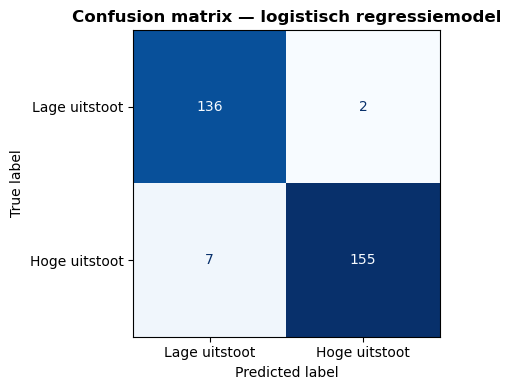

In [ ]:
# Python: Train een nieuw model op de nieuwe target.
# Gebruik hierbij alleen de vijf meest invloedrijke onafhankelijke variabelen die je eerder hebt gekozen.
# stratify=y_klasse zorgt voor een evenredige verdeling van klassen in train en test.

X_log = df_transformed[top5_vars]

X_tr_log, X_te_log, y_tr_log, y_te_log = train_test_split(
    X_log, y_klasse, test_size=0.2, random_state=42, stratify=y_klasse
)

log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_tr_log, y_tr_log)

y_pred_log = log_model.predict(X_te_log)

# ── Resultaten ────────────────────────────────────────────────────────────────
print("=== Logistisch regressiemodel (top 5 variabelen) ===\n")
print(classification_report(y_te_log, y_pred_log,
                             target_names=['Lage uitstoot (0)', 'Hoge uitstoot (1)']))

# ── Confusion matrix ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_te_log, y_pred_log)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Lage uitstoot', 'Hoge uitstoot'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion matrix — logistisch regressiemodel', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Regressieformule ──────────────────────────────────────────────────────────
print("\n=== Logistische regressieformule ===")
print(f"Intercept (b0): {log_model.intercept_[0]:.4f}\n")
for var, coef in zip(top5_vars, log_model.coef_[0]):
    print(f"  {var}: {coef:.4f}")

z_formule = f"z = {log_model.intercept_[0]:.2f}"
for var, coef in zip(top5_vars, log_model.coef_[0]):
    teken = '+' if coef >= 0 else '-'
    z_formule += f" {teken} {abs(coef):.2f}·{var}"
print(f"\nz-score formule:\n  {z_formule}")
print("\nP(hoge uitstoot) = 1 / (1 + e^(-z))")


<div style="font-family: 'Times New Roman', serif; line-height: 1.3;">

---

# Conclusie

In dit onderzoek hebben wij de jaarlijkse CO₂-uitstoot van 1500 Nederlandse burgers geanalyseerd aan de hand van beschrijvende statistieken, visualisaties, kansrekening, een statistische toets en twee regressiemodellen.

<br>

## Onderzoeksvraag 1 — Welke factoren verklaren de CO₂-uitstoot?

Uit de correlatiematrix blijkt dat het aantal autokilometers per jaar de sterkste samenhang heeft met de jaarlijkse CO₂-uitstoot (r ≈ 0,903 — een zeer sterke positieve correlatie). Vliegkilometers en OV-gebruik dragen eveneens bij, zij het in mindere mate. Sociaaldemografische kenmerken zoals leeftijd, gewicht en opleidingsniveau hebben een beduidend kleinere directe invloed. Dit bevestigt dat **mobiliteitsgedrag de primaire verklaring** vormt voor verschillen in individuele uitstoot.

De Mann-Whitney U toets toont een statistisch significant verschil in de verdeling van CO₂-uitstoot tussen personen met en zonder auto (U = 455.357, p < 0,001, rank-biserial r ≈ groot effect). Personen met een auto hebben een duidelijk hogere mediane uitstoot (≈ 6.414 kg) ten opzichte van personen zonder auto (≈ 1.076 kg).

<br>

## Onderzoeksvraag 2 — In welke mate kan de uitstoot worden voorspeld?

Het lineaire regressiemodel met alle variabelen (Model 1) behaalde op de testset R² ≈ 0,937 en RMSE ≈ 824,59 kg. Via 20-fold cross-validatie scoorde Model 1 gemiddeld R² ≈ 0,9076 (RMSE ≈ 1.015,19 kg) en Model 2 (top 5 variabelen) gemiddeld R² ≈ 0,9042 (RMSE ≈ 1.035,97 kg).

De Wilcoxon signed-rank toets op de RMSE-scores per fold liet een p-waarde zien van p ≈ 0,053. Omdat p ≥ 0,05 wordt H₀ **niet** verworpen: er is geen statistisch significant verschil in nauwkeurigheid tussen de twee modellen. Het vereenvoudigde model met vijf variabelen presteert daarmee nagenoeg even goed als het volledige model.

Het logistisch regressiemodel classificeerde burgers als hoge of lage uitstooter met een accuracy van circa **97%** op de testset, opnieuw op basis van slechts vijf kenmerken.

<br>

## Kansrekening

De kans dat een willekeurige burger meer dan 5.000 kg CO₂ per jaar uitstoot bedraagt circa **49%** op basis van de standaard normaalverdeling. Dit laat zien dat 5.000 kg zeer dicht bij het gemiddelde van de dataset ligt, wat aangeeft dat de uitstoot breed verdeeld is over de populatie.

<br>

## Algemene conclusie

Mobiliteitsgedrag — met name autogebruik en vliegreizen — is de dominante factor bij het verklaren van individuele CO₂-uitstoot. Een beperkte set van vijf variabelen is al voldoende voor een nauwkeurige schatting. **Let op:** de analyse toont samenhang en voorspellende waarde, maar bewijst geen oorzaak-gevolgrelatie. Gerichte interventies op mobiliteitsgedrag kunnen mogelijk klimaatwinst opleveren, maar dit vereist nader causaal onderzoek.

</div>


<div style="font-family: 'Times New Roman', serif; line-height: 1.3;">

---

# Testen van de Modellen

In dit hoofdstuk testen wij de twee getrainde modellen op persoonlijke data. Vul de `persoon` dict in met jouw eigen gegevens en run de cellen om de voorspellingen te zien.

</div>


In [ ]:
# ── Controleer eerst de beschikbare categorieën in de dataset ─────────────────
print("--- Beschikbare categorieën per nominale/ordinale variabele ---")
for col in ['geslacht', 'burgerlijke_staat', 'autobezit', 'fietsbezit',
            'elektrisch_auto', 'gebruik_carsharing', 'opleiding_niveau']:
    print(f"  {col}: {sorted(df[col].dropna().unique())}")

# ── Persoonlijke data — vul hier jouw eigen gegevens in ──────────────────────
# Gebruik EXACT de categoriewaarden zoals hierboven getoond.

lucasH = {
    # Ratio variabelen
    'leeftijd':                              27,
    'gewicht_KG':                            85,
    'jaarsalaris_eu':                        0,
    'huishouden_grootte':                    1,
    'km_auto_per_jaar':                      200,
    'km_fiets_per_jaar':                     0,
    'km_ov_per_jaar':                        20000,
    'km_vliegtuig_per_jaar':                 0,
    'dagen_thuiswerken_per_week_pro_rato':   0,
    'dagen_kantoorwerken_per_week_pro_rato': 0,
    'dagen_in_buitenland_per_jaar':          0,

    # Nominale variabelen (gebruik exact dezelfde schrijfwijze als in de dataset)
    'geslacht':           'man',
    'burgerlijke_staat':  'ongehuwd',
    'stad':               'Haarlem',
    'provincie':          'Noord-Holland',
    'autobezit':          'nee',
    'fietsbezit':         'nee',
    'elektrisch_auto':    'nee',
    'gebruik_carsharing': 'nooit',   # controleer bovenstaande output

    # Ordinale variabele
    'opleiding_niveau':   'hbo',
}

lucasvH = {
    # Ratio variabelen
    'leeftijd':                              21,
    'gewicht_KG':                            86,
    'jaarsalaris_eu':                        10000,
    'huishouden_grootte':                    4,
    'km_auto_per_jaar':                      0,
    'km_fiets_per_jaar':                     1000,
    'km_ov_per_jaar':                        15000,
    'km_vliegtuig_per_jaar':                 6000,
    'dagen_thuiswerken_per_week_pro_rato':   0,
    'dagen_kantoorwerken_per_week_pro_rato': 1,
    'dagen_in_buitenland_per_jaar':          20,

    # Nominale variabelen
    'geslacht':           'man',
    'burgerlijke_staat':  'ongehuwd',
    'stad':               'Leiden',
    'provincie':          'Zuid-Holland',
    'autobezit':          'nee',
    'fietsbezit':         'ja',
    'elektrisch_auto':    'nee',
    'gebruik_carsharing': 'nooit',   # controleer bovenstaande output

    # Ordinale variabele
    'opleiding_niveau':   'hbo',
}

robinD = {
    # Ratio variabelen
    'leeftijd':                              20,
    'gewicht_KG':                            68,
    'jaarsalaris_eu':                        8000,
    'huishouden_grootte':                    4,
    'km_auto_per_jaar':                      2400,
    'km_fiets_per_jaar':                     0,
    'km_ov_per_jaar':                        2500,
    'km_vliegtuig_per_jaar':                 0,
    'dagen_thuiswerken_per_week_pro_rato':   0,
    'dagen_kantoorwerken_per_week_pro_rato': 2.0,
    'dagen_in_buitenland_per_jaar':          0,

    # Nominale variabelen
    'geslacht':           'man',
    'burgerlijke_staat':  'ongehuwd',
    'stad':               'Den Haag',
    'provincie':          'Zuid-Holland',
    'autobezit':          'nee',
    'fietsbezit':         'ja',
    'elektrisch_auto':    'nee',
    'gebruik_carsharing': 'nooit',   # controleer bovenstaande output

    # Ordinale variabele
    'opleiding_niveau':   'hbo',
}

namen    = ['Lucas H', 'Lucas vH', 'Robin D']
personen = [lucasH, lucasvH, robinD]

# ── Transformeer alle personen naar hetzelfde formaat als df_transformed ──────
personen_transformed_list = []
for persoon in personen:
    persoon_df  = pd.DataFrame([persoon])

    ratio_scaled = pd.DataFrame(scaler.transform(persoon_df[ratio]), columns=ratio)

    ord_val = pd.DataFrame({'opleiding_niveau': [opleiding_volgorde.get(persoon['opleiding_niveau'].lower(), 0)]})
    if carsharing_is_ordinaal:
        ord_val['gebruik_carsharing'] = carsharing_volgorde.get(persoon['gebruik_carsharing'].lower(), 0)

    ohe_val = pd.get_dummies(persoon_df[nominaal], drop_first=True).astype(int)
    ohe_val = ohe_val.reindex(columns=df_ohe.columns, fill_value=0)

    pt = pd.concat([ratio_scaled, ord_val, ohe_val], axis=1)
    pt = pt.reindex(columns=X.columns, fill_value=0)
    personen_transformed_list.append(pt)

personen_transformed = pd.concat(personen_transformed_list, ignore_index=True)
print("\nTransformatie klaar voor:", namen)


Transformatie klaar voor: ['Lucas H', 'Lucas vH', 'Robin D']


In [ ]:
# ── Lineaire regressie: voorspelling voor alle 3 personen ────────────────────
co2_lin_all  = model_all.predict(personen_transformed)
co2_lin_top5 = model_top5.predict(personen_transformed[top5_vars])

print("=== Lineaire regressie — voorspelling CO₂-uitstoot per jaar ===\n")
print(f"{'Naam':<14} {'Model 1 (alle vars)':>20} {'Model 2 (top 5)':>17}")
print("-" * 55)
for naam, co2_all, co2_t5 in zip(namen, co2_lin_all, co2_lin_top5):
    print(f"  {naam:<12} {co2_all:>18.2f} KG  {co2_t5:>14.2f} KG")


=== Lineaire regressie (Model 1 — alle variabelen) ===
  Lucas H        → 2389.89 KG per jaar
  Lucas vH       → 3909.83 KG per jaar
  Robin D        → 1724.86 KG per jaar


In [148]:
# ── Logistische regressie: voorspelling voor alle 3 personen ─────────────────
personen_log_input = personen_transformed[top5_vars]

klassen    = log_model.predict(personen_log_input)
kansen_all = log_model.predict_proba(personen_log_input)

print("--- Logistische regressie (top 5 variabelen) ---")
for naam, klasse, kansen in zip(namen, klassen, kansen_all):
    label = 'Hoge uitstoot (≥ mediaan)' if klasse == 1 else 'Lage uitstoot (< mediaan)'
    print(f"\n  {naam}:")
    print(f"    Klasse:           {klasse} — {label}")
    print(f"    Kans lage  (0):   {kansen[0]*100:.1f}%")
    print(f"    Kans hoge  (1):   {kansen[1]*100:.1f}%")

print(f"\nAfkapwaarde (mediaan): {afkapwaarde:.2f} KG")


--- Logistische regressie (top 5 variabelen) ---

  Lucas H:
    Klasse:           0 — Lage uitstoot (< mediaan)
    Kans lage  (0):   99.0%
    Kans hoge  (1):   1.0%

  Lucas vH:
    Klasse:           0 — Lage uitstoot (< mediaan)
    Kans lage  (0):   99.2%
    Kans hoge  (1):   0.8%

  Robin D:
    Klasse:           0 — Lage uitstoot (< mediaan)
    Kans lage  (0):   95.7%
    Kans hoge  (1):   4.3%

Afkapwaarde (mediaan): 4677.28 KG
